<a href="https://colab.research.google.com/github/Ritesh-panda/datascience-learnings/blob/main/Classification_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
display(df[['TotalCharges']].info())

Missing values in TotalCharges after conversion: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TotalCharges  7032 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


None

In [6]:
df.dropna(subset=['TotalCharges'], inplace=True)
print(f'Rows remaining: {len(df)}')
display(df.isnull().sum())

Rows remaining: 7032


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.Churn.value_counts()/len(df)*100

,count
Churn,
No,73.421502
Yes,26.578498


In [9]:
x=df.drop(['customerID','Churn'],axis=1)

In [10]:
y=df.Churn.values

In [11]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [12]:
y

array(['No', 'No', 'Yes', ..., 'No', 'Yes', 'No'], dtype=object)

In [13]:
# Identify categorical columns (excluding numeric ones)
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()

# Apply dummy encoding
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

print("Encoded features shape:", x.shape)
display(x.head())

Encoded features shape: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [15]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


**KNN Classifier**

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model_1=KNeighborsClassifier()
model_1.fit(x_train,y_train)


KNeighborsClassifier()

In [47]:
y_pred1=model_1.predict(x_test)
y_pred1

array(['Yes', 'No', 'No', ..., 'Yes', 'No', 'Yes'], dtype=object)

In [48]:
print(accuracy_score(y_test,y_pred1)*100)


75.52


**DT Classifier**

In [49]:

from sklearn.tree import DecisionTreeClassifier
model_2=DecisionTreeClassifier()
model_2.fit(x_train,y_train)

DecisionTreeClassifier()

In [50]:
y_pred2=model_2.predict(x_test)
y_pred2

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [51]:
print(accuracy_score(y_test,y_pred2)*100)

72.46222222222222


**Random Forest Classifier**

In [56]:
from sklearn.ensemble import RandomForestClassifier
model_3=RandomForestClassifier(n_estimators=200)
model_3.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200)

In [57]:
y_pred3=model_3.predict(x_test)
y_pred3

array(['No', 'No', 'No', ..., 'Yes', 'No', 'No'], dtype=object)

In [58]:
print(accuracy_score(y_test,y_pred3)*100)

78.52444444444444


Naive Bayes classifier

In [59]:
from sklearn.naive_bayes import  BernoulliNB
model_4=BernoulliNB()
model_4.fit(x_train,y_train)

BernoulliNB()

In [65]:
y_pred4=model_4.predict(x_test)
y_pred4

array(['Yes', 'Yes', 'Yes', ..., 'Yes', 'No', 'Yes'], dtype='<U3')

In [62]:
print(accuracy_score(y_test,y_pred4)*100)

73.26222222222222


SVM Classifier

In [63]:
from sklearn.svm import SVC
model_5=SVC()
model_5.fit(x_train,y_train)

SVC()

In [66]:
y_pred5=model_5.predict(x_test)
y_pred5

array(['No', 'No', 'No', ..., 'Yes', 'No', 'No'], dtype=object)

In [67]:
print(accuracy_score(y_test,y_pred5)*100)

79.55555555555556


LOGISTICS REGRESSION

In [68]:
from sklearn.linear_model import LogisticRegression
model_6=LogisticRegression()
model_6.fit(x_train,y_train)


LogisticRegression()

In [69]:
y_pred6=model_6.predict(x_test)
y_pred6

array(['No', 'No', 'No', ..., 'Yes', 'No', 'No'], dtype=object)

In [70]:
print(accuracy_score(y_test,y_pred6)*100)

80.40888888888888


# Task
Generate detailed classification reports for all trained models (KNN, Decision Tree, Random Forest, Naive Bayes, SVM, and Logistic Regression) using `sklearn.metrics.classification_report` to evaluate their precision, recall, and F1-score. Consolidate these metrics into a pandas DataFrame for a side-by-side comparison and create a multi-metric bar chart using Seaborn to visualize performance differences. Finally, provide a recommendation for the best model to identify churners in the dataset from "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv" based on the balance of accuracy and recall.

## Generate Detailed Classification Reports

### Subtask:
Iterate through all trained models and print their full classification reports using sklearn.metrics.classification_report.


**Reasoning**:
Generate a comprehensive classification report for all six models to evaluate their performance across different metrics like precision, recall, and F1-score.



In [71]:
from sklearn.metrics import classification_report

# Mapping model names to their respective predictions
model_predictions = {
    "KNN Classifier": y_pred1,
    "Decision Tree Classifier": y_pred2,
    "Random Forest Classifier": y_pred3,
    "Naive Bayes Classifier": y_pred4,
    "SVM Classifier": y_pred5,
    "Logistic Regression": y_pred6
}

# Iterating through each model and printing the classification report
for model_name, predictions in model_predictions.items():
    print(f"{'='*30}\n{model_name} Report\n{'='*30}")
    print(classification_report(y_test, predictions))
    print("\n")

KNN Classifier Report
              precision    recall  f1-score   support

          No       0.82      0.85      0.84      4130
         Yes       0.54      0.50      0.52      1495

    accuracy                           0.76      5625
   macro avg       0.68      0.67      0.68      5625
weighted avg       0.75      0.76      0.75      5625



Decision Tree Classifier Report
              precision    recall  f1-score   support

          No       0.82      0.80      0.81      4130
         Yes       0.48      0.51      0.50      1495

    accuracy                           0.72      5625
   macro avg       0.65      0.66      0.65      5625
weighted avg       0.73      0.72      0.73      5625



Random Forest Classifier Report
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      4130
         Yes       0.63      0.46      0.53      1495

    accuracy                           0.79      5625
   macro avg       0.73      0.68     

## Consolidate Performance Metrics

### Subtask:
Create a pandas DataFrame that summarizes the performance metrics for each model to facilitate a direct side-by-side comparison.


**Reasoning**:
I will create a consolidated DataFrame that summarizes the performance metrics (Accuracy, Precision, Recall, and F1-Score) for the 'Yes' class across all trained models to facilitate a side-by-side comparison.



In [72]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

results = []

# Mapping model names to their respective predictions (already defined in previous cells)
for model_name, predictions in model_predictions.items():
    # Calculate overall accuracy
    acc = accuracy_score(y_test, predictions)

    # Extract precision, recall, and f1-score for the 'Yes' class (churners)
    # pos_label='Yes' ensures we get metrics for the churn class
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='binary', pos_label='Yes')

    results.append({
        'Model Name': model_name,
        'Accuracy': acc,
        'Precision (Yes)': precision,
        'Recall (Yes)': recall,
        'F1-Score (Yes)': f1
    })

# Create the summary DataFrame
metrics_df = pd.DataFrame(results)

# Display the consolidated results
print("Summary of Model Performance (Churn Class: 'Yes')")
display(metrics_df.sort_values(by='Accuracy', ascending=False))

Summary of Model Performance (Churn Class: 'Yes')


,Model Name,Accuracy,Precision (Yes),Recall (Yes),F1-Score (Yes)
5,Logistic Regression,0.804089,0.666103,0.527090,0.588499
4,SVM Classifier,0.795556,0.679501,0.436789,0.531759
2,Random Forest Classifier,0.785244,0.630336,0.464214,0.534669
0,KNN Classifier,0.755200,0.542630,0.502341,0.521709
3,Naive Bayes Classifier,0.732622,0.498108,0.792642,0.611771
1,Decision Tree Classifier,0.724622,0.482976,0.512375,0.497241


## Visualize Model Performance Comparison

### Subtask:
Create a multi-metric bar chart using Seaborn to visually compare the performance of all models across different metrics (Accuracy and F1-Score).


**Reasoning**:
I will reshape the metrics_df into a long format and use Seaborn to create a grouped bar chart comparing Accuracy and F1-Score across all models, as requested by the user instructions.



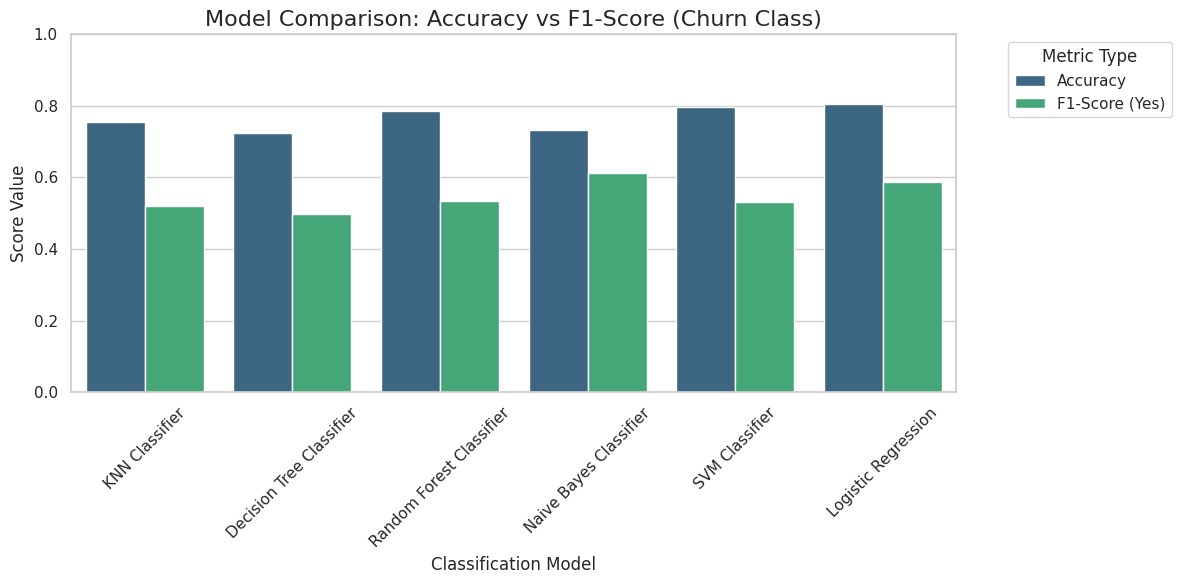

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reshape metrics_df to long format for Seaborn plotting
plot_df = pd.melt(metrics_df, id_vars=['Model Name'],
                  value_vars=['Accuracy', 'F1-Score (Yes)'],
                  var_name='Metric', value_name='Score')

# 2. Set visual style
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# 3. Create grouped bar chart
ax = sns.barplot(data=plot_df, x='Model Name', y='Score', hue='Metric', palette='viridis')

# 4. Add title and labels
plt.title('Model Comparison: Accuracy vs F1-Score (Churn Class)', fontsize=16)
plt.xlabel('Classification Model', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.ylim(0, 1.0)  # Scores are between 0 and 1

# 5. Adjust layout and rotate x-axis labels for legibility
plt.xticks(rotation=45)
plt.legend(title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Final Task

### Subtask:
Analyze the model comparison metrics and provide a final recommendation for the best model to identify churners.


## Summary:

### Q&A

**Which model is best for identifying churners based on the balance of accuracy and recall?**
While **Logistic Regression** achieved the highest overall accuracy (\$80.41\%\$), the **Naive Bayes Classifier** is the most effective for identifying churners specifically. It achieved the highest recall (\$79.26\%\$) and the highest F1-Score (\$0.6118\$), indicating it captures the largest proportion of actual churners despite a lower overall accuracy of \$73.26\%\$.

### Data Analysis Key Findings

*   **Model Accuracy:** Logistic Regression and SVM Classifier lead in overall accuracy at \$80.41\%\$ and \$79.56\%\$ respectively.
*   **Churn Detection (Recall):** Naive Bayes significantly outperformed all other models in identifying actual churners with a recall of \$79.26\%\$. In comparison, the high-accuracy Logistic Regression only captured \$52.71\%\$ of churners.
*   **Precision and Reliability:** SVM achieved the highest Precision (\$67.95\%\$), meaning that when it predicts a customer will churn, it is the most likely to be correct.
*   **Balanced Performance:** The F1-Score, which balances precision and recall for the churn class, ranks the models as follows:
    1.  Naive Bayes (\$0.6118\$)
    2.  Logistic Regression (\$0.5885\$)
    3.  Random Forest (\$0.5347\$)
    4.  SVM (\$0.5318\$)
    5.  KNN (\$0.5217\$)
    6.  Decision Tree (\$0.4972\$)

### Insights or Next Steps

*   **Business Strategy Alignment:** Choose **Naive Bayes** if the business priority is to catch as many potential churners as possible (High Recall) even at the cost of some false alarms. Choose **Logistic Regression** if the goal is a more balanced approach with higher overall prediction reliability.
*   **Next Steps:** Consider performing hyperparameter tuning on the Logistic Regression and Random Forest models to see if their recall can be improved without significantly sacrificing accuracy, or explore Ensemble methods (like Gradient Boosting) which often provide a better balance for imbalanced datasets like customer churn.
